---
---

# **Group 40 Report**
Arthur Bauer, Chelsea Davidson, Eleonore Salin, Quitterie Vermeulen

---

## **Team Contributions**

This project was a collaborative effort with each team member taking ownership of specific modules while contributing to overall system integration and debugging.

| Team Member | Primary Responsibilities |
|-------------|--------------------------|
| **Chelsea Davidson** | Vision system - ArUco marker detection, homography, obstacle detection, coordinate transformations, visualization utilities |
| **Eleonore Salin** | Extended Kalman Filter - state estimation, sensor fusion, process and measurement noise tuning, variance computation experiments |
| **Quitterie Vermeulen** | Global navigation - A*/Dijkstra pathfinding, obstacle expansion, path simplification, support with vision module |
| **Arthur Bauer** | Local navigation - obstacle avoidance maneuver, IR sensor logic, kidnap detection; Motion control - Astolfi controller, waypoint tracking; Main loop architecture |
| **All Members** | System integration, module interfacing, debugging, parameter tuning, testing |

---

## **Introduction**

This project implements an autonomous navigation system for the Thymio robot capable of path planning, obstacle avoidance, and robust state estimation. The robot navigates from a start position to a goal in a known environment while avoiding both static and dynamic obstacles.

### System Architecture

The system is organized into six modular components:

1. **Vision** - Camera-based localization and environment mapping using ArUco markers
2. **Global Navigation** - A*/Dijkstra path planning on an occupancy grid
3. **Local Navigation** - Reactive obstacle avoidance using IR proximity sensors
4. **Filtering** - Extended Kalman Filter for sensor fusion and state estimation
5. **Motion Control** - Astolfi controller for smooth waypoint tracking
6. **Main Loop** - Real-time integration and mode switching logic

**Design Philosophy:** The architecture separates high-level planning (global navigation) from low-level reactive behaviors (local navigation), enabling robust operation in partially observable environments. Sensor fusion through the EKF maintains accurate state estimates even when camera measurements are unavailable.

---

### Physical Setup

The environment consists of:

- **Arena:** Square workspace with white background
- **Markers:** ArUco markers define arena boundaries (IDs 1, 2), robot pose (ID 0), and goal location (ID 3)
- **Obstacles:** Red paper cutouts detected via color segmentation
- **Robot:** Thymio differential drive with 5 front IR sensors and 2 ground sensors

<div style="text-align: left;">
  <img src="environment.jpg" alt="Environment setup" style="width: 400px; height: auto;">
</div>

**Key Design Choices:**

| Choice | Rationale |
|--------|-----------|
| ArUco markers | Robust detection under varying illumination; unique IDs enable feature identification |
| Red obstacles | Best color contrast against white background after empirical testing |
| Square arena | Simplifies grid-based path planning and coordinate transformations |
| 200×200 grid | Balances path quality with computational efficiency (10 Hz main loop) |

---

### Software Dependencies

```python
import numpy as np          # Grid operations and linear algebra
import cv2                  # Computer vision and marker detection
import matplotlib.pyplot    # Path visualization
import heapq               # Priority queue for A* algorithm
import asyncio             # Asynchronous sensor communication
import math                # Trigonometric calculations
from tdmclient import *    # Thymio robot interface
```

The codebase is structured as importable Python modules (`vision.py`, `global_nav.py`, `local_nav.py`, `filtering.py`, `motion_controll.py`, `thymio.py`, `utils.py`) with a main execution loop demonstrating full system integration.


## **Main System Integration and Control Loop**

The main program orchestrates all modules of the project — vision, global navigation, local navigation, filtering, and motor control — to enable the Thymio robot to autonomously follow a path, avoid obstacles, and maintain an accurate state estimate.

---

### 1. Vision and Environment Initialisation

A `Vision` instance is created at startup, responsible for:  

- Detecting the arena boundaries.  
- Building the occupancy grid.  
- Providing coordinate transformations between pixels, centimetres, and grid cells.

The initial robot pose is obtained from the camera and converted into grid coordinates:
```python
start_cell = real_to_grid(100 * start_pos)
```

This allows the global planner to compute a collision-free path from the robot’s start position to the goal.  

**Design choice:** Using the camera at startup ensures that the filter and planners start from an informed state. Converting to centimetres keeps units consistent with the filtering and motion control modules.

---

### 2. Global Path Planning

The global navigation module computes a path on the occupancy grid:  

- The robot is treated as a point by expanding obstacles.  
- Users can choose between Dijkstra or A* algorithms.  
- The result is a simplified list of waypoints:
```python
path = [(x1, y1), (x2, y2), ..., (xn, yn)]
```

**Design choice:** A* is generally preferred for efficiency. Path simplification reduces unnecessary computation during motion following.

---

### 3. Thymio and Filter Initialisation

All the filter initialisation is done inside the filtering file by the function:
```python
init_filter(q_x, q_y, q_theta, q_v, r_x, r_y, r_theta, initial_pos=None, initial_orient=None)
```

The Thymio robot is connected, and its initial state is set according to camera measurements:
```python
x0 = [x0, y0, θ0, v0]
P0 = 1000 * I4
```

The Extended Kalman Filter (EKF) is initialised with:  

- Process noise `Q` for position, orientation, and velocity.  
- Measurement noise `R` from the camera.  
- A large initial covariance to reflect uncertainty.

**Design choice:** Large initial `P0` ensures that early camera measurements have a strong influence on the state estimate.

---

### 4. Navigation Modes and Switching

The main loop continuously updates the robot state and selects the navigation mode:  

- **GLOBAL:** Follows the planned path. Waypoints are popped as they are reached. EKF provides smooth position estimates.  
- **LOCAL:** Triggered by IR-detected obstacles. Executes obstacle avoidance. Once cleared, a new global path is computed.  
- **KIDNAPPED:** Triggered by ground sensors detecting robot lift. Stops the robot. Waits for vision to re-localise the robot. Reinitialises global path and filter state if detected.

**Design choice:** Mode switching is based on sensor thresholds and counters to avoid oscillations between states.

---

### 5. Main Loop Execution

Each iteration performs:

1. **Sensor update**  
   IR and ground sensors are refreshed. Determines obstacle presence or kidnapped state.

2. **EKF update**  
   Inputs: motor speeds and optional camera measurements.  
   Updates robot estimate:

```python
x_{k+1}, P_{k+1} = EKF(x_k, P_k, u_k, z_k)
```

`zk` is set to camera measurement if available; otherwise, odometry-only update is performed.

3. **Data storage for visualisation**  
   Every 5 frames, positions are logged for both raw camera and filtered estimates:
```python
cam_robot_positions_cm.append([x_cam, y_cam])
filter_robot_positions_cm.append([x_est, y_est])
axes_cm = [sqrt(P[0,0]), sqrt(P[1,1])]
angle = θ_est
```

4. **Visualisation**  
   Planned path, raw camera positions, filtered trajectory, and covariance ellipse are displayed in real-time. The ellipse represents the uncertainty along the robot’s forward and lateral axes, providing immediate visual feedback of EKF confidence. Helps verify navigation accuracy.

5. **Timing control**  
   Ensures a fixed loop frequency:
```python
Δt = 1 / FREQ_MAIN_LOOP
```
The EKF update relies on consistent time steps for both prediction and correction. Also control commands for the Thymio should be spaced evenly to avoid oscillations or jerky motion.

**Design choice:** The timing control ensures consistent EKF predictions, stable motor commands, and regular visualisation updates. It also adapts naturally if some iterations take longer due to heavy computation (like vision processing), maintaining overall system stability.

---

### 6. Termination

The loop exits when all waypoints are reached or upon user interruption.  
Motors are stopped, and the camera window is closed:

```python
thymio.stop()
cv2.destroyAllWindows()
```

## Main loop

In [ ]:
# External modules import
import matplotlib.pyplot as plt
import numpy as np
import cv2
import time
import asyncio
import math

# Internal modules and thymio class import
from thymio import Thymio
from vision import Vision
import motion_controll
import filtering
import local_nav
import global_nav
import utils

# ============================================================
#  CONSTANTS FOR MAIN LOOP
# ============================================================
GL_NAV_CHANGE_THLD = 20  # Number of cycles without obstacle to switch back to global navigation
WAIT_AFTER_KIDNAP = 20   # Number of cycles to wait for robot re-detection after kidnap

# ============================================================
#  VISION AND ENVIRONMENT INITIALIZATION
# ============================================================
# Initialize vision system - detects arena, obstacles, and creates occupancy grid
visionInstance = Vision() # Calls getEnvironment which stores the arena and creates the grid

# Get cell size for coordinate conversions
cell_size_cm = visionInstance.getCellSizeCm()

# Get start position and orientation from camera
ret, frame = visionInstance.cap.read() #Taking a single image to find the start pos of the robot
if not ret:
    raise ValueError("Camera failed to capture the frame.")

start_pos, start_orient = visionInstance.getInitialRobotPose()
print(start_pos, start_orient)

# Convert to grid coordinates (start_pos is in meters, convert to cm first)
if start_pos:
    start_cell = utils.real_to_grid((start_pos[0]*100, start_pos[1]*100))
    goal_pos = visionInstance.getGoalPos()
    goal_cell = utils.real_to_grid((goal_pos[0]*100, goal_pos[1]*100))  # Goal in cm

# Get the grid from vision
grid = visionInstance.grid

# ============================================================
#  GLOBAL PATH PLANNING
# ============================================================
# Find path to goal (mode = "a_star" or "djikstra")
# 0 for djikstra, 1 for a*
path_find_mode = 1
path, expanded_grid = global_nav.find_path(path_find_mode, grid, start_cell, goal_cell)

global_nav.display_grid(expanded_grid, start_cell, goal_cell)

# ============================================================
#  THYMIO INITIALIZATION
# ============================================================
# Initialize and connect to Thymio robot
thymio = Thymio(pos_init=start_pos, orient=start_orient)
await thymio._connect_to_thymio_()
thymio.stop()

# ============================================================
#  LOOP VARIABLES INITIALIZATION
# ============================================================
vis_cntr = 0  # Counter for visualization updates

# Local navigation state variables
kidnaped_cntr = 0            # Counter for robot re-detection after kidnap
avoid_right = True           # Direction to avoid obstacle (True=right, False=left)
LN_orient = 0                # Stored orientation when entering local navigation
LN_pos_at_obst = [0, 0]      # Position where obstacle was first detected
LN_stage = 0                 # Current stage in wall-following state machine
obstacle_avoided = False     # Flag indicating obstacle avoidance complete
is_kidnaped = False          # Flag indicating robot is lifted

# Trajectory tracking
robot_trajectory = []  # List to store (x_cm, y_cm) positions

# ============================================================
#  FILTER INITIALIZATION
# ============================================================
# Initialize Extended Kalman Filter with process and measurement noise
x_est, P_est, Q, R = filtering.init_filter(utils.q_x, utils.q_y, utils.q_theta, utils.q_v, utils.r_x,
                                           utils.r_y, utils.r_theta, start_pos*100, start_orient)

# ============================================================
#  VISUALIZATION DATA STRUCTURES
# ============================================================
# Initialize robot position data and global path for visualizations
cam_robot_positions_cm = []      # Raw camera measurements (x, y) in cm
filter_robot_positions_cm = []   # Filtered position estimates (x, y) in cm
global_path_points_cm = path.copy()  # Copy of global path for visualization
# Store last ellipse info for visualization (covariance ellipse)
ellipse_params = None  

# ============================================================
#  MAIN CONTROL LOOP
# ============================================================
while(True):
    start_loop_time = time.time()
    
    # Update IR proximity sensors and ground sensors
    await thymio.update_ir()
    await thymio.update_ground_sensors()

    # Check for obstacles and kidnap events
    is_object = local_nav.is_object(thymio)
    is_kidnaped = local_nav.check_kidnap(thymio)

    # If robot is lifted, stop immediately and switch to KIDNAPPED mode
    if(is_kidnaped):
        thymio.nav_mode = "KIDNAPPED"
        thymio.stop()

    # If obstacle detected during global navigation, switch to local avoidance
    if(is_object and thymio.nav_mode=="GLOBAL"):
        avoid_right = local_nav.avoid_right(thymio, grid)  # Determine avoidance direction
        thymio.nav_mode = "LOCAL"
    
    # When obstacle successfully avoided, replan path and return to global mode
    if(obstacle_avoided):
        if(thymio.nav_mode=="GLOBAL"):
            print("Error: obstacle_avoided true in global nav")
            break
        else:
            # Reset local navigation state
            obstacle_avoided = False
            LN_stage = 0
            thymio.nav_mode = "GLOBAL"
            
            # Replan path from current position to goal
            robot_cell = utils.real_to_grid((thymio.pos[0], thymio.pos[1]))
            path, expanded_grid = global_nav.find_path(path_find_mode, grid, robot_cell, goal_cell)
            global_path_points_cm = path.copy()
    
    # Wait for robot to be placed back and re-detected by camera
    if(thymio.nav_mode == "KIDNAPPED" and not is_kidnaped):
        kidnaped_cntr += 1
        if kidnaped_cntr < WAIT_AFTER_KIDNAP:
            # Attempt to re-detect robot position
            ret, frame = visionInstance.cap.read() 
            if not ret:
                print("Camera failed to capture the frame.")
                break

            vis = frame.copy()
            result = visionInstance.getRobotPoseAndVisualise(frame, vis)

            # Check if detection successful
            if result[0] is None:
                print("Robot not detected during kidnap wait")
            else:
                # Robot re-detected, reinitialize state and path
                kidnaped_cntr = 0
                thymio.nav_mode = "GLOBAL"
                thymio.pos[0] = result[0][0]*100  # Convert m to cm
                thymio.pos[1] = result[0][1]*100
                thymio.orient = result[1]
                
                # Replan path from new position
                robot_cell = utils.real_to_grid((thymio.pos[0], thymio.pos[1]))
                path, expanded_grid = global_nav.find_path(path_find_mode, grid, robot_cell, goal_cell)
                global_path_points_cm = path.copy()
                print("Robot re-localized, switching to GLOBAL navigation")

    # Execute navigation based on current mode
    match thymio.nav_mode:
        case "KIDNAPPED":
            # Stop the robot and wait for re-placement
            thymio.stop()
        
        case "LOCAL":
            # Execute wall-following obstacle avoidance
            obstacle_avoided, LN_stage, LN_pos_at_obst, LN_orient = local_nav.avoid_obstacle(thymio, avoid_right, LN_stage, LN_pos_at_obst, LN_orient)

        case "GLOBAL":
            # Follow planned path to next waypoint
            next_wp = path[0]
            wp_reached = motion_controll.follow_path(thymio, next_wp)
            if(wp_reached):
                # Remove reached waypoint from path
                path.pop(0)
                if len(path) == 0:
                    # All waypoints reached, mission complete
                    print("Goal reached")
                    thymio.stop()
                    break

    # Store current orientation for next iteration's delta calculation
    thymio.last_orient = thymio.orient
    
    # Capture new frame for robot pose detection
    ret, frame = visionInstance.cap.read() 
    if not ret:
        print("Camera failed to capture the frame.")
        break

    vis = frame.copy() # Copy frame for visualization overlay
    visionInstance.visualiseArena(vis, visionInstance.arena_corners_pixels)
    # Visualize global navigation path
    visionInstance.visualiseGlobalPath(vis, global_path_points_cm)

    # Detect robot pose from camera
    result = visionInstance.getRobotPoseAndVisualise(frame, vis)
    
    # Update filter with or without camera measurement
    if result[0] is None:
        # Camera detection failed - use odometry-only prediction
        x_est, P_est = filtering.filter_pos(thymio, [None, None, None, 0], x_est,
                                        P_est, Q, R, 1/utils.FREQ_MAIN_LOOP, utils.RATIO_SPEED)
    else:
        # Camera detection successful - fuse with odometry
        [X_robot, Y_robot], robot_heading_angle = result
        x_est, P_est = filtering.filter_pos(thymio, [X_robot*100, Y_robot*100, robot_heading_angle, 0], x_est, # *100 to put it in cm
                                        P_est, Q, R, 1/utils.FREQ_MAIN_LOOP, utils.RATIO_SPEED)

    # Update robot state with filtered estimates
    thymio.pos = [x_est[0], x_est[1]]
    thymio.orient = x_est[2]

    # Store position data every 5 frames for visualization
    if (vis_cntr == 0 or vis_cntr % 5 == 0):
        if (result[0] is not None):
            cam_robot_positions_cm.append([result[0][0]*100, result[0][1]*100]) # Convert m to cm
        filter_robot_positions_cm.append([x_est[0], x_est[1]])

        # Store covariance ellipse parameters for uncertainty visualization
        ellipse_params = { "center_cm": [x_est[0], x_est[1]],                       # Estimated position in cm
                           "axis_cm": [np.sqrt(P_est[0,0]), np.sqrt(P_est[1,1])],   # Standard deviations from covariance
                           "angle_rad": x_est[2]}                                    # Robot heading

    # Draw uncertainty ellipse on camera frame (updated every 5 frames)
    if ellipse_params is not None:
        cx_cm, cy_cm = ellipse_params["center_cm"]
        ax_cm, ay_cm = ellipse_params["axis_cm"]
        angle_rad = ellipse_params["angle_rad"]

        # Convert ellipse center from world to pixel coordinates
        pixel_pos = visionInstance.globalToCamera(cx_cm/100, cy_cm/100)
        if pixel_pos is not None:
            # Convert axes to pixel space by computing axis endpoints
            px1, _ = visionInstance.globalToCamera((cx_cm+ax_cm)/100, cy_cm/100)    # X-axis endpoint in pixels
            _, py2 = visionInstance.globalToCamera(cx_cm/100, (cy_cm+ay_cm)/100)    # Y-axis endpoint in pixels
            axis_x_pix = int(abs(px1 - pixel_pos[0]))       # Semi-major axis in pixels
            axis_y_pix = int(abs(py2 - pixel_pos[1]))       # Semi-minor axis in pixels
            
            # Draw covariance ellipse
            cv2.ellipse(vis, center=(int(pixel_pos[0]), int(pixel_pos[1])),
                        axes=(axis_x_pix, axis_y_pix), angle=-np.degrees(angle_rad),  # Negative for coordinate frame conversion
                        startAngle=0, endAngle=360, color=(0,0,0), thickness=2) 

    # Draw filtered trajectory (orange) and raw camera trajectory (blue)
    visionInstance.visualiseGlobalPath(vis, filter_robot_positions_cm, (0, 215, 255))  # Orange: filtered path
    visionInstance.visualiseGlobalPath(vis, cam_robot_positions_cm, (255, 0, 0))       # Blue: camera measurements
    vis_cntr += 1

    # Display live camera feed with all visualizations (scaled 1.5x for better visibility)
    vis_large = cv2.resize(vis, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)
    cv2.imshow("Live camera", vis_large)
    if(cv2.waitKey(1) & 0xFF == ord('q')):
        thymio.stop()
        break

    # Maintain constant loop frequency for consistent EKF updates
    time_main_loop = time.time() - start_loop_time
    print(f"Main loop time: {time_main_loop:.3f} s")
    if(time_main_loop < 1/utils.FREQ_MAIN_LOOP):
        await asyncio.sleep(1/utils.FREQ_MAIN_LOOP - time_main_loop)
    herz_main_loop = 1 / (time.time() - start_loop_time)
    print(f"Herz main loop: {herz_main_loop:.4f}")

# ============================================================
#  CLEANUP
# ============================================================
# Wait for user to close window
while(True):
    if(cv2.waitKey(1) & 0xFF == ord('q')):
        cv2.destroyAllWindows()
        break

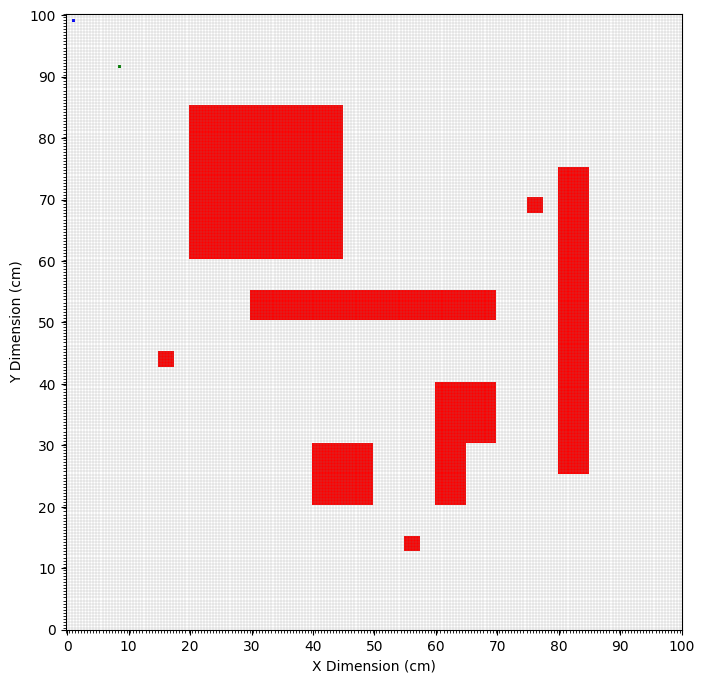

In [ ]:
# External modules import
import matplotlib.pyplot as plt
import numpy as np
import cv2
import time
import asyncio
import math

# Internal modules and thymio class import
from thymio import Thymio
from vision import Vision
import motion_controll
import filtering
import local_nav
import global_nav
import utils

# Initialize cell_size_cm for test grid (assuming 100cm arena)
utils.cell_size_cm = 100 / utils.GRID_DIM  # 0.5 cm per cell
utils.arena_width_cm = 100
utils.arena_height_cm = 100

test_grid = utils.create_test_grid()
start_cell = (2, 2)
goal_cell = (17, 17)

global_nav.display_grid(test_grid, start_cell, goal_cell)

In [ ]:
pip install opencv-python

---
---

## **Thymio Class**

The `Thymio` class (`thymio.py`) provides a Python interface to the Thymio robot hardware using the `tdmclient` library. It encapsulates robot state, sensor reading, and motor control.

---

### 1. State Management

The class maintains the robot's state variables:

| Attribute | Description |
|-----------|-------------|
| `pos` | Position [x, y] in cm |
| `orient` | Orientation in radians |
| `nav_mode` | Navigation mode: "GLOBAL", "LOCAL", or "KIDNAPPED" |
| `ir_sensors` | 5 front IR proximity values |
| `ground_sensors` | 2 ground proximity values for kidnap detection |
| `motor_speeds` | Current left and right motor speeds |

**Design choice:** Storing both current and previous orientation (`last_orient`) enables angular velocity computation for odometry.

---

### 2. Connection and Communication

```python
async def _connect_to_thymio_(self):
    self.node = await self.client.wait_for_node()
    await self.node.lock()
```

Establishes asynchronous connection to the Thymio via `ClientAsync` and locks the node for exclusive access.

---

### 3. Sensor Reading

#### IR Proximity Sensors

```python
async def update_ir(self):
    await self.node.wait_for_variables({"prox.horizontal"})
    self.ir_sensors = self.node["prox.horizontal"][0:5]
```

Reads the 5 front horizontal IR sensors used for obstacle detection.

#### Ground Sensors

```python
async def update_ground_sensors(self):
    await self.node.wait_for_variables({"prox.ground.reflected"})
    self.ground_sensors = list(self.node["prox.ground.reflected"])
```

Reads ground proximity sensors. Values drop when the robot is lifted, enabling kidnap detection.

---

### 4. Motor Control

```python
def set_motor_speeds(self, speeds):
    speeds = [max(-500, min(500, s)) for s in speeds]  # Saturation
    self.motor_speeds = speeds
    self.node.send_set_variables({
        "motor.left.target": [speeds[0]], 
        "motor.right.target": [speeds[1]]
    })
```

Sets motor speeds with saturation at ±500 to prevent hardware damage. The speeds are sent to the robot and stored locally for odometry calculations.

**Design choice:** Speed saturation prevents commands exceeding physical limits, ensuring safe operation.

---

### 5. Integration with Other Modules

The class serves as the central interface between high-level control logic and hardware:

- **Filtering:** Provides motor speeds for odometry-based prediction
- **Local Navigation:** Supplies IR sensor values for obstacle detection
- **Motion Control:** Receives motor commands from path-following algorithms
- **Vision/EKF:** Position and orientation updated by external modules via `set_pos()`

**Button interface:** The class includes a `button_loop()` method for manual control, used during variance computation experiments but not in the final autonomous navigation system.

This abstraction separates hardware communication from navigation logic, enabling modular development and testing.

This demonstrates basic usage of the Thymio class for sensor reading and motor control.

---

### 6. Integration Example

In [ ]:
# Thymio Class - Integration Example
from thymio import Thymio
import asyncio

# Initialize and connect to robot
thymio = Thymio(pos_init=[20, 30], orient=0)
await thymio._connect_to_thymio_()

# Read sensors
await thymio.update_ir()
await thymio.update_ground_sensors()

print(f"IR sensors: {thymio.ir_sensors}")
print(f"Ground sensors: {thymio.ground_sensors}")

# Set motor speeds
thymio.set_motor_speeds([150, 150])  # Move forward
await asyncio.sleep(2)

thymio.set_motor_speeds([100, -100])  # Rotate
await asyncio.sleep(1)

thymio.stop()

# Access state
print(f"Position: {thymio.pos}")
print(f"Orientation: {thymio.orient}")
print(f"Navigation mode: {thymio.nav_mode}")

---
---

## **Constants and Coordinate Transformations**

The `utils.py` module centralizes project-wide constants and provides coordinate transformation functions between different reference frames.

---

### 1. System Constants

The module defines key parameters used throughout the project:

| Category | Constants | Description |
|----------|-----------|-------------|
| **Grid** | `GRID_DIM = 200` | Occupancy grid dimension (200×200 cells) |
| **Robot** | `ROBOT_H = 11 cm`, `ROBOT_W = 11 cm` | Thymio physical dimensions |
| **Control** | `FREQ_MAIN_LOOP = 10 Hz` | Main loop execution frequency |
| **Odometry** | `RATIO_SPEED = 28.839` | Motor speed to cm/s conversion factor |
| **Planning** | `SAFETY_MARGIN = 10 cells` | Obstacle expansion for collision avoidance |

**Design choice:** Centralizing constants in a single module ensures consistency across all files and simplifies parameter tuning.

---

### 2. Filter Noise Parameters

Variance values computed experimentally for the Extended Kalman Filter:

```python
# Process noise (Q matrix)
q_x = 0.00076067      # Position x uncertainty
q_y = 0.00023067      # Position y uncertainty  
q_theta = 0.00025994  # Orientation uncertainty
q_v = 0.300625        # Velocity uncertainty

# Measurement noise (R matrix)
r_x = 0.00076067      # Camera x measurement noise
r_y = 0.00023067      # Camera y measurement noise
r_theta = 0.00025994  # Camera angle measurement noise
```

These values were determined through systematic variance experiments described in the Filtering section.

---

### 3. Coordinate Systems

The project uses two reference frames:

1. **Grid coordinates** `(row, col)`:
   - Origin (0, 0) = TOP-LEFT of arena
   - Row increases DOWNWARD (0 to 199)
   - Column increases RIGHTWARD (0 to 199)

2. **Real-world coordinates** `(x_cm, y_cm)`:
   - Origin (0, 0) = BOTTOM-LEFT of arena
   - X increases RIGHTWARD
   - Y increases UPWARD

---

### 4. Transformation Functions

#### Cell ↔ Centimeter Conversion

```python
def cell_to_cm(cell_index):
    return cell_index * cell_size_cm

def cm_to_cell(cm_value):
    return int(cm_value / cell_size_cm)
```

Converts between discrete grid indices and continuous metric distances.

#### Real ↔ Grid Conversion

```python
def real_to_grid(coord):
    x_cm, y_cm = coord
    col = int(x_cm / cell_size_cm)
    row = GRID_DIM - 1 - int(y_cm / cell_size_cm)  # Y-axis flip
    return (row, col)

def grid_to_real(coord):
    row, col = coord
    x_cm = (col + 0.5) * cell_size_cm
    y_cm = (GRID_DIM - 1 - row + 0.5) * cell_size_cm
    return (x_cm, y_cm)
```

**Key transformations:**
- **Y-axis inversion:** Grid rows increase downward, while real Y increases upward
- **Cell centering:** `grid_to_real()` returns the center of each cell by adding 0.5
- **Clamping:** `real_to_grid()` ensures coordinates stay within valid grid bounds [0, 199]

**Design choice:** These functions enable seamless integration between the vision system (pixel/metric coordinates), path planning (grid cells), and motion control (centimeters).

---

### 5. Integration Example

```python
# Vision detects robot at (x=45.2 cm, y=38.7 cm)
robot_cell = real_to_grid((45.2, 38.7))  # → (161, 45)

# Global planner computes path in grid coordinates
path = [(161, 45), (150, 50), (140, 55), ...]

# Motion controller converts waypoint to real coordinates
next_wp_cm = grid_to_real(path[0])  # → (45.5, 38.5)
```

This abstraction layer allows each module to work in its natural coordinate system while maintaining consistency across the entire navigation pipeline.

In [6]:
# Utils - Coordinate Transformations Example
import utils

# Vision detects robot at (x=45.2 cm, y=38.7 cm)
robot_cell = utils.real_to_grid((45.2, 38.7))
print(f"Robot position in grid coordinates: {robot_cell}")

# Global planner computes path in grid coordinates
path = [(161, 45), (150, 50), (140, 55)]

# Motion controller converts waypoint to real coordinates
next_wp_cm = utils.grid_to_real(path[0])
print(f"Next waypoint in real coordinates: {next_wp_cm}")

# Demonstrate cell/cm conversions
cell_idx = 100
cm_value = utils.cell_to_cm(cell_idx)
print(f"Cell {cell_idx} = {cm_value:.2f} cm")

back_to_cell = utils.cm_to_cell(cm_value)
print(f"{cm_value:.2f} cm = cell {back_to_cell}")

Robot position in grid coordinates: (122, 90)
Next waypoint in real coordinates: (22.75, 19.25)
Cell 100 = 50.00 cm
50.00 cm = cell 100


---
---

## **Vision**

The computer vision class is responsible for identifying and visualising all features in the environment (arena, start position, goal, and global obstacles) as well the live pose of the robot. The static features of the environment are detected once at the start, whereas the pose of the robot is detected continuously throughout execution.

The class is defined in `vision.py`.

#### Key Design Choices
* We chose to use ArUco markers for the arena corners, goal, and robot location as their high contrast provides robustness under illumination changes and the unique ID allows each feature to be individually identifiable.
* We chose to use a square arena to allow for easy conversion to a grid. The grid allows for simpler global path planning techniques (using cells).
---

### 1. Getting the Environment

When the Vision class is constructed, it immediately calls:

    getEnvironment()

This initialises the camera capture (stores it for later use to avoid startup delay) and extracts all static, environment-level information (arena, start, goal, obstacles) and stores it for later use. 

The function calls the following components:


#### 1.1 getArenaCornerPixelsAndRealArenaSize(frame)

##### Purpose

Detect two ArUco markers (IDs **1** and **2**) representing the bottom left and top right corners of the arena respectively. These markers define:
* the arena boundary in **pixel coordinates**
* the arena boundary in **world coordinates** (from printed marker size)
* the mapping between the two (homography)

##### Theory

ArUco detection returns the 2D corner positions of each marker in pixel coordinates.
Since we know the marker's physical size (3cm sides), we can use the distance between corners of a marker to establish a pixel-to-meter scaling and use this to obtain the physical dimensions of the arena. We define this arena as our global coordinate system where (0,0) is at the center of the bottom left marker. We can then use the arena corners in pixel and world coordinates to define the homography for the environment.


#### 1.2 getRobotPoseCameraFrame(frame)

##### Purpose

Detect the ArUco marker with ID **0**, which is the marker placed on the top of the robot. 

We printed the ArUco marker so that it **covers the entire top surface**, making:

* detection more robust
* the marker centre coincide with the robot's geometric centre
* orientation estimation accurate and consistent

###### Theory

OpenCV's ArUco module provides the corner points of the robot marker ($p_i$ for $i=0,1,2,3$). These corner points can be used to identify the center coordinates, $C$:

$
C_x = \frac{1}{4} \sum_{i=0}^{3} p_{i, x}
$

$
C_y = \frac{1}{4} \sum_{i=0}^{3} p_{i, y}
$

They can also be used to calculate the robot's heading direction. In the image below you can see the top left and top right corner points of the ArUco marker with ID 0. 

<div style="text-align: center;">
  <img src="headingCalculation.png" alt="Heading calculation visualisation" style="width: 500px; height: auto;">
  <h3>Heading calculation visualisation</h3>
</div>

To get the vector that goes along the front side, you do:

$
v = v_{TR} - v_{TL}
$

To get the angle that this makes with the horizontal, you do:
$
\theta = \arctan2(-{\Delta y}, {\Delta x})
$

Note the $-\Delta y$ due to the difference between the y axis definition in the camera frame (downwards direction) and our defined frame (upwards direction). 

However, observe that this doesn't actually give you the heading direction if we view the top edge as the front of the robot, it gives you $\pi/2$ clockwise from it. So, we just placed the ArUco marker such that the right hand side represented the robot's forward direction (orange arrow).

#### 1.3 cameraToGlobal (Homography)

##### Purpose

Convert any pixel coordinate from the camera frame into world coordinates (meters) inside the arena.

This allows us to take detections (robot pose, obstacles, goal) in image space and express them in the global coordinate frame used by navigation and planning.


#### Theory: 2D Homography

A homography is a planar projective transformation that maps points from one plane to another.
Because the arena floor is flat, all relevant features lie on a single plane, so the homography maps:

**camera pixel space → real-world coordinate space**

A homography is represented as a 3×3 matrix:

$
H =
\begin{bmatrix}
h_{11} & h_{12} & h_{13} \\
h_{21} & h_{22} & h_{23} \\
h_{31} & h_{32} & h_{33}
\end{bmatrix}
$

Points are expressed in homogeneous coordinates, meaning the pixel (u, v) becomes:

$
\mathbf{p}_{camera} =
\begin{bmatrix}
u \\ v \\ 1
\end{bmatrix}
$

The mapping is:

$
\mathbf{p_{world}}' =
H * \mathbf{p_{camera}} =
\begin{bmatrix}
X' \\ Y' \\ W'
\end{bmatrix}
$

Since homogeneous coordinates are scale-invariant, the homography introduces a scale factor. This can be removed using normalisation. So, the real world point is recovered by dividing by (W'):

$
X = \frac{X'}{W'}
\qquad
Y = \frac{Y'}{W'}
$

##### Computing the Homography

We obtain four pixel-space arena corners from ArUco markers:
* bottom-left
* bottom-right
* top-right
* top-left

We also define the corresponding real-world coordinates in meters:
* (0,0)
* (width, 0)
* (width, height)
* (0, height)

Given these four point correspondences, the homography (H) is solved by minimising:

$
H=argmin_H \sum_i​∥p_{world,i}​−H*p_{camera,i}​∥
$

This is a least-squares optimisation over the entries of the matrix (H).

Rather than solving this manually, we use OpenCV's built-in solver:

`H, _ = cv2.findHomography(pixel_pts, world_pts)`

OpenCV internally performs the projective least-squares fit using the Direct Linear Transform (DLT) algorithm.

##### Using the Homography (camera → world)

To convert any pixel point (u, v):

1. Convert to homogeneous coordinates
2. Multiply by the homography
3. Divide by (W')

$
\begin{bmatrix}
X' \\ Y' \\ W'
\end{bmatrix} = H
\begin{bmatrix}
u \\ v \\ 1
\end{bmatrix}
$

$
X = \frac{X'}{W'} \\
Y = \frac{Y'}{W'}
$

#### 1.4 locateObstaclesRed(frame)

##### Purpose

Detect **all red obstacles**, extract their contour boundaries, and approximate them as polygons.
Storing obstacles as polygons provides:

* shape generalisation
* an easy way to convert polygons from camera to world coordinates (using their verticies)
* a simple way to provide information to the `createGrid()` function

##### Why red?

After empirical testing with several colours (blue, green, yellow, black), **red** objects resulted in:
* the best contrast against the arena floor
* minimal confusion with ArUco markers (black/white)
* most stable colour segmentation across lighting conditions

##### Theory: Colour Segmentation

We convert the image to HSV, because hue is brightness-invariant.
Typical red thresholding uses two ranges because red wraps around the hue wheel:

```python
lower1 = (0, 70, 50)
upper1 = (10, 255, 255)
lower2 = (170, 70, 50)
upper2 = (180, 255, 255)
```

The binary mask is:

$
M(u,v) = \begin{cases}
1 & \text{if } \text{HSV}(u,v) \in \text{red-range}, \
0 & \text{otherwise}
\end{cases}
$

To clean noise:

* **GaussianBlur** (remove pixel-level noise)
* **morphological opening** (remove specks)
* **closing** (fill small holes)

##### Theory: Polygon Approximation
Now that we have a cleaned mask, we try to identify contours and approximate their shape with polygons. 
1. Contour Detection (`cv2.findContours`):

    Contours are simply continuous curves that follow the boundary of a blob in a binary image. Given our cleaned red mask, `cv2.findContours()` scans the image using border-following algorithms (like Suzuki-Abe) to find the set of points that lie on the edge of a red object. We use `cv2.RETR_EXTERNAL` so that we only detect the outermost contour, ignoring holes and nested shapes. We use `cv2.CHAIN_APPROX_NONE` to keep as much detail as possible. Although this increases computation, this is done once at the start and so extra computation doesn't negatively impact main loop frequency. 

2. Polygon Approximation (Ramer–Douglas–Peucker Algorithm):

    Since contours can contain hundreds or thousands of points (inefficient and unnecessary for defining obstacle in the world frame), we simplify them using:

    `poly = cv2.approxPolyDP(cnt, epsilon, True)`
    
    which uses the uses the Ramer–Douglas–Peucker (RDP) algorithm which converts a dense contour into a simpler polygon while preserving overall shape (subject to an epsilon defining the allowed distance between the polygon and a point in the contour that is not in the polygon). We define epsilon proportional to the contour perimiter to account for different shape sizes. We use a small epsilon (0.1% of the perimeter) to keep as much detail as possible. As mentioned above, this increased computation does not negatively impact the main loop frequency as this is done once at the start and then the obstacle information is stored in the grid which is a fixed size.

#### 1.5 convertPolygonsToWorld

Each polygon vertex (camera pixel) is converted via:

$
\mathbf{p}_{world}' = H * \mathbf{p}_{camera}
$

Once normalised, this produces **world-frame polygons** which get stored in the grid and used by global navigation.



#### 1.6 findGoalPos(frame)

Detects ArUco marker with ID **3** and converts its centre from camera to world using the same homography.
This keeps all environment features in a consistent coordinate system.


#### 1.7 createGrid

##### Purpose

Create an occupancy grid representation of the environment.

We use the arena's global size (from ArUco detection) to define grid bounds.
Each obstacle polygon is rasterised into the grid and stored with a value of -1, representing untraversable space.

Grid resolution is chosen as a compromise between:

* allowing global planning to identify a smooth and accurate path
* planning runtime

The arena is represented as a **200x200 cell grid** (defined in `utils.py`):

| Value | Meaning |
|-------|---------|
| `0`   | Free space |
| `-1`  | Obstacle |

##### Coordinate Systems

There are two coordinate systems:

1. **Grid coordinates** `(row, col)`:
   - Row 0 = TOP, row 199 = BOTTOM  
   - Column 0 = LEFT, column 199 = RIGHT

2. **Real-world coordinates** `(x_cm, y_cm)`:
   - Origin (0, 0) = BOTTOM-LEFT  
   - X increases to the right, Y increases upward

Conversion functions in `utils.py`:
- `real_to_grid(coord)`
- `grid_to_real(coord)`
- `cm_to_cell(cm_value)`
- `cell_to_cm(cell_index)`

---

### 2. Visualisation Utilities

We modularise the visualisation system so individual components can be enabled/disabled independently.
These functions operate solely in **camera pixel space**, using the detected pixels or the inverse homography when visualising global-calculated points (like the global path).

#### 2.1 visualiseArena

Draws the arena square.

#### 2.2 visualiseRobotPose

Draws the marker bounding box, robot's center position, and robot's heading direction as an arrow.

#### 2.3 visualiseObstacles

Draws each obstacle polygon.

#### 2.4 visualiseGoalPos

Draws a bounding box around the goal marker and highlights the center position.

#### 2.5 visualiseGlobalPoint / visualiseGlobalPath
Given a world coordinate ($\mathbf{p}_{world}$), it converts this point to camera pixel coordinates using the inverse of the homography:

$
\mathbf{p}_{camera}' = H^{-1} \mathbf{p}_{world}
$

Once normalised, it then draws that pixel location on the camera frame. To visualise a path, it draws straight lines between sequential points.

The path visualisation includes a sampling safeguard:

```python
if len(path) > 200:
    path = sample(path, 200)
```

This prevents the visualiser from slowing the main loop (and disrupting the operational frequency) during long episodes (many robot location points).

---

### 3. Live Feedback
Since we have defined our detection functions in a modular way (they take a frame and detect the specific feature), we are able to obtain the live robot pose by obtaining a frame from the initialised video capture inside the main loop and calling `getRobotPose(frame)`. 

---
### 4. Integration Example

In [8]:
visionInstanceDemo = Vision() # Calls getEnvrionment() which detects and stores all static environmental features

if not visionInstanceDemo.cap.isOpened(): # Use the already initialised videoCapture 
    print("Error: Could not access the webcam.")
    exit()

# Obtain the live robot pose and visualise it
while True:
    ret, frame = visionInstanceDemo.cap.read()
    if not ret:
        print("Camera failed to capture the frame.")
        break

    vis = frame.copy() # Create a copy of the frame to be able to visualise the image without affecting detection

    # Redraw arena outline
    visionInstanceDemo.visualiseArena(vis, visionInstanceDemo.arena_corners_pixels)

    # Detect and draw robot pose
    position, robot_heading_angle = visionInstanceDemo.getRobotPoseAndVisualise(frame, vis)
    if (position is None or robot_heading_angle is None):
        continue
    [X, Y] = position

    path = [[X*100, Y*100], [40, 40], [50, 60], [70, 70]] # Visualise a random global path that starts at the robot's position
    visionInstanceDemo.visualiseGlobalPath(vis, path)

    # Show the live window
    cv2.imshow("Live Robot Pose", vis)

    # Exit on Q
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

visionInstanceDemo.cap.release()
cv2.destroyAllWindows()

Error: Could not access the webcam.


SystemExit: 

Below is an example visualisation obtained from the getEnvironment() function: 
<div style="text-align: center;">
  <img src="getEnvironmentVisualisation.jpg" alt="getEnvrionment visualisation" style="width: 500px; height: auto;">
</div>

---
---

## **Global Navigation**

This part explains the global navigation module (`global_nav.py`) used for path planning in the Mobile Robotics Project.

The global navigation system finds a collision-free path from a **start** position to a **goal** position on a 2D occupancy grid. It uses:

1. **Obstacle Expansion** - Grow obstacles by the robot's size so we can treat the robot as a point  
2. **A* or Dijkstra Search** - Find the shortest path on the expanded grid  
3. **Path Simplification** - Reduce the cell-by-cell path to key waypoints  
4. **Visualization** - Display the results on the map

---

### 1. Obstacle Expansion

This function grows obstacles outward by the robot's size so that the pathfinding algorithm can treat the robot as a single point instead of checking its full footprint at every step.

The kernel size determines how much we expand the obstacle in all directions. We expand by half of the robot's size and add a small safety margin to make sure no overlap will occur between the obstacle and the robot.

We chose a circular kernel as we found during testing that it best matched our needs of obstacle avoidance and the robot's way of moving.

<div style="text-align: center;">
  <img src="grid.png" alt="Original Grid" width="400"/> <img src="expanded_grid.png" alt="Expanded Grid" width="400"/>
  <p><em>Left: Original occupancy grid with obstacles at actual size. Right: Expanded grid after morphological dilation.</em></p>
</div>

**Left:** Original occupancy grid from vision system. Obstacles (red) are detected at their actual size. The robot would need collision checking against its full footprint during pathfinding.

**Right:** Expanded grid after morphological dilation. Obstacles are grown by the robot's radius plus a safety margin. This allows the pathfinding algorithm to treat the robot as a point, simplifying the search while guaranteeing collision-free paths.

---

### 2. Pathfinding Algorithm

For this part, we adapted the code from the exercise session 5 of the course. The changes we made were : 
- using a grid with expanded obstacles,
- using the 8 connected neighbouring cells on the grid, 
```python 
directions = [
            (-1, 0), (1, 0), (0, -1), (0, 1),  # Cardinal
            (-1, -1), (-1, 1), (1, -1), (1, 1)  # Diagonal
             ]
```
- change in the heuristic function.

The user can choose between 2 pathfinding algorithms. 

#### Dijkstra

This algorithm assigns distances to each cell with start=0. Then, at each step, the unvisited node with the smallest known distance is picked. It has a greedy approach and explores cells outwards from the start until the goal is reached. The path can then be reconstructed by backtracking.

#### A star

**Heuristic Function**

- A* uses a heuristic to estimate distance to the goal. Because movement is 8-directional, we use the **octile distance**. 
(Reference for heuristic function choice : https://theory.stanford.edu/~amitp/GameProgramming/Heuristics.html)

- Diagonal moves cost `sqrt(2) = ~1.414`, straight moves cost `1`.  Optimal path: move diagonally as much as possible, then straight.

```python 
def heuristic(r, c):
    dx = abs(r[0] - c[0])
    dy = abs(r[1] - c[1])
    # D = 1, D_diag = sqrt(2)
    return max(dx, dy) + (np.sqrt(2) - 1) * min(dx, dy)
```

**Pathfinding**

A star works in the same way as Dijkstra's Algorithm but adds the heuristic function to guide the path finding towards the goal and therefore explore less cells.

We tested with both pathfinding algorithms and found that both work very well in our environment. The only noticeable difference was that A* gave us a smoother path.

---

### 3. Path Simplification

The path returned by the pathfinding algorithms give each cell the robot passes on. This is not efficient at all so we simplify this path by only taking the **corner waypoints**. 

The code looks at each cell in the path and checks the direction, if the direction of point X is the same as point X+1, we remove point X+1 from the list of cells. Then so on until we reach a point with a different direction, this one will be kept in the simplified path list.

<img src="simplify.png" alt="Simplify" width="200"/>

---

### 4. Results

Both pathfinding algorithms successfully compute collision-free paths from start to goal on the expanded grid.

<div style="text-align: center;">
  <img src="path_gl_nav_djik.png" alt="Dijkstra Path" height="400"/> <img src="path_gl_nav.png" alt="A* Path" height="400"/>
  <p><em>Left: Path found using Dijkstra's algorithm. Right: Path found using A* algorithm.</em></p>
</div>

**Dijkstra (Left):** Explores uniformly in all directions from the start, guaranteeing the shortest path. The algorithm expands cells based purely on distance traveled, without considering proximity to the goal. This results in a more exhaustive search.

**A\* (Right):** Uses the octile distance heuristic to guide the search toward the goal. The heuristic focuses exploration on promising directions, resulting in fewer cells explored and a visually smoother path. Both paths have similar lengths, but A* achieves the solution more efficiently.

**Observations:**
- Both algorithms find optimal or near-optimal paths around obstacles
- A* produces slightly smoother trajectories due to its goal-directed heuristic
- Path simplification reduces both paths to key waypoints for efficient motion control
- The expanded grid ensures all computed paths maintain safe clearance from obstacles

---

### 5. Integration Example

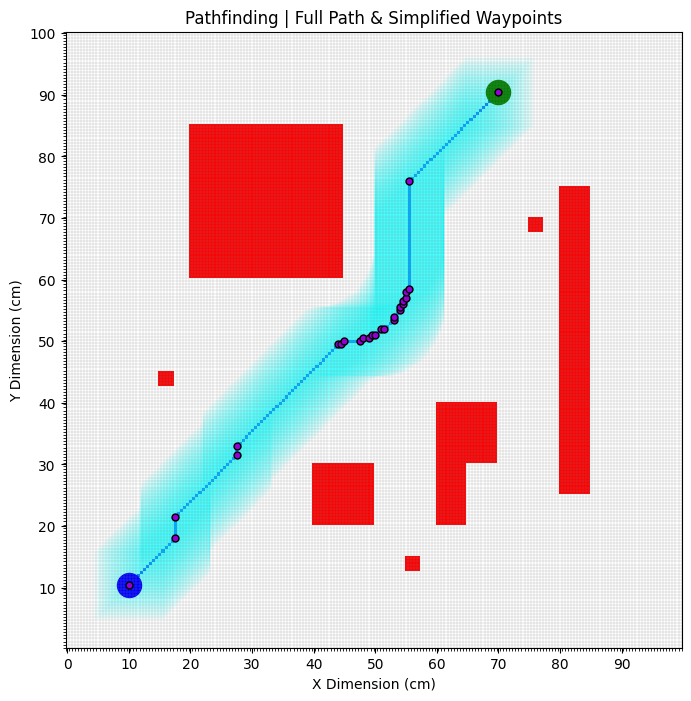

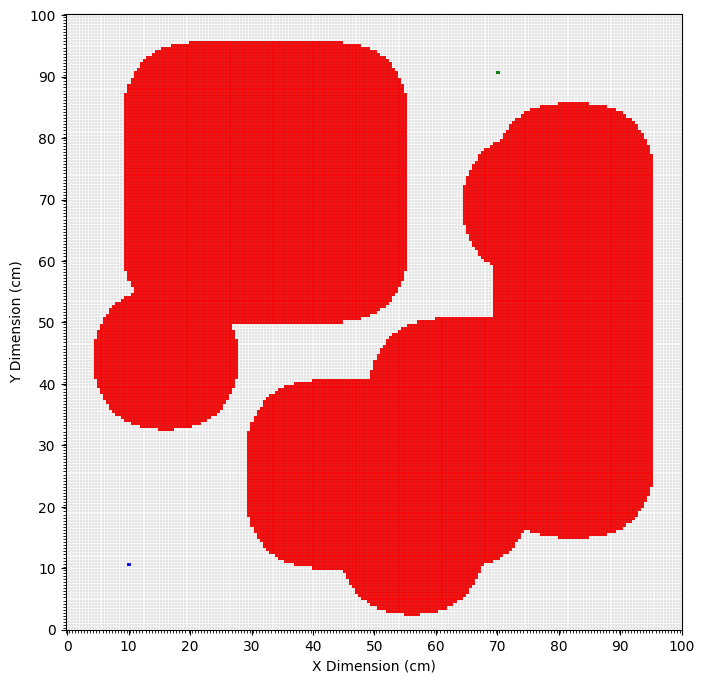

Path found with 26 waypoints


In [5]:
# External modules import
import matplotlib.pyplot as plt
import numpy as np
import cv2
import time
import asyncio
import math

# Internal modules and thymio class import
from thymio import Thymio
from vision import Vision
import motion_controll
import filtering
import local_nav
import global_nav
import utils

# Initialize cell_size_cm for test grid (assuming 100cm arena)
utils.cell_size_cm = 100 / utils.GRID_DIM  # 0.5 cm per cell
utils.arena_width_cm = 100
utils.arena_height_cm = 100

# Define start and goal positions (in cm)
start_cm = (10.0, 10.0)
goal_cm = (70.0, 90.0)

# Convert to grid coordinates
start_cell = utils.real_to_grid(start_cm)
goal_cell = utils.real_to_grid(goal_cm)

test_grid = utils.create_test_grid()

# Find path (0 for Dijkstra, 1 for A*)
path, expanded_grid = global_nav.find_path(1, test_grid, start_cell, goal_cell)

# Display result
global_nav.display_grid(expanded_grid, start_cell, goal_cell)
print(f"Path found with {len(path)} waypoints")

---
---

## **Local Navigation**

This section explains the **local navigation** module (`local_nav.py`) responsible for reactive obstacle avoidance when unexpected obstacles are encountered during execution.

The local navigation system provides a safety layer that handles obstacles not present in the initial map using real-time sensor feedback.

---

### 1. Navigation Modes

The system operates in three distinct modes:

| Mode | Description | Trigger |
|------|-------------|---------|
| `GLOBAL` | Follows planned path | Default mode |
| `LOCAL` | Reactive obstacle avoidance | IR sensors detect obstacle |
| `KIDNAPPED` | Robot lifted, awaits replacement | Ground sensors detect lift-off |

---

### 2. Obstacle Detection

#### IR Sensor Thresholds

The system uses different IR thresholds depending on the navigation mode:

```python
GLOBAL_IR_THLD = 3500   # Higher threshold for early detection
LOCAL_IR_THLD = 2000    # Lower threshold during avoidance
```

**Design choice:** The higher threshold in GLOBAL mode provides early warning of obstacles, allowing the robot to switch to LOCAL mode before collision. The lower threshold in LOCAL mode prevents premature exit from avoidance maneuvers due to sensor noise.

#### Detection Logic

```python
def is_object(thym: Thymio):
    ir_max = max(thym.ir_sensors)
    if(thym.nav_mode == "GLOBAL" and ir_max > GLOBAL_IR_THLD or
       thym.nav_mode == "LOCAL" and ir_max > LOCAL_IR_THLD):
        return True
    return False
```

The function returns `True` when any of the 5 front-facing IR sensors exceeds the mode-specific threshold.

---

### 3. Avoidance Direction Decision

Before starting the avoidance maneuver, the robot analyzes the environment to determine whether to avoid left or right.

#### Grid Analysis

The `avoid_right()` function scans a rectangular region ahead of the robot:

- **Forward depth:** 30 cells (FORW_DEP_ANALYSE)
- **Lateral distance:** 50 cells on each side (LAT_DIS_ANALYSE)

For each forward distance, the function counts obstacles on both the left and right sides:

```python
for fwd_dist in range(0, FORW_DEP_ANALYSE):
    for lateral_dist in range(1, LAT_DIS_ANALYSE):
        # Count obstacles on right and left
        if grid[right_position] == -1:
            obstacles_right += 1
        if grid[left_position] == -1:
            obstacles_left += 1
```

**Decision:** The robot avoids toward the side with **fewer obstacles** to maximize free space during the maneuver.

**Design choice:** Using the occupancy grid rather than just IR sensors provides better situational awareness, preventing the robot from turning into dead ends or areas with multiple obstacles.

---

### 4. Four-Stage Avoidance Maneuver

The obstacle avoidance follows a state machine with 4 sequential stages:

#### Stage 0: Initial Rotation

Rotate away from the obstacle until IR sensors no longer detect it:

```python
if sum(ir_sens) > 0:
    thym.set_motor_speeds([ROT_SPEED, -ROT_SPEED])  # Rotate left to avoid right
else:
    stage = 1  # All sensors clear, proceed to advance
```

**Purpose:** Clear the immediate obstacle from the robot's path before moving forward.

#### Stage 1: First Advance

Move forward by `ADVENCE_DIST1 = 3/4 × ROBOT_HEIGHT` to create lateral clearance:

```python
thym.set_motor_speeds([FWD_SPEED, FWD_SPEED])
distance_traveled = sqrt((x - x_start)² + (y - y_start)²)
if distance_traveled >= ADVENCE_DIST1:
    stage = 2
```

**Purpose:** Move far enough to clear the obstacle's edge before attempting to return to the original path.

#### Stage 2: Return Rotation

Rotate back toward the original heading until either:
- The obstacle is re-detected (indicating the robot has cleared it), OR
- Maximum rotation angle is reached (MAX_ROT_ANGLE = 1.7 rad ≈ 97°)

```python
thym.set_motor_speeds([-ROT_SPEED, ROT_SPEED])  # Rotate right to return
angle_difference = current_angle - saved_angle
if ir_sens[0] > 0 or abs(angle_difference) >= MAX_ROT_ANGLE:
    stage = 3
```

**Design choice:** Re-detecting the obstacle confirms the robot has passed it. The angle limit prevents infinite rotation if the obstacle extends far laterally.

#### Stage 3: Final Advance

Move forward by `ADVENCE_DIST2 = 3/2 × ROBOT_HEIGHT` to completely clear the obstacle:

```python
thym.set_motor_speeds([FWD_SPEED, FWD_SPEED])
if distance_traveled >= ADVENCE_DIST2:
    return True  # Obstacle avoided, return to GLOBAL mode
```

**Purpose:** Ensure sufficient clearance before resuming global path following.

---

### 5. Kidnap Detection and Recovery

#### Ground Sensor Monitoring

The robot continuously monitors ground sensors to detect if it has been lifted:

```python
KIDNAP_THRESHOLD = 100

def check_kidnap(thym: Thymio):
    if max(thym.ground_sensors) < KIDNAP_THRESHOLD:
        return True  # Robot lifted
    return False
```

#### Recovery Procedure

When kidnap is detected:

1. **Stop immediately:** `thymio.stop()`
2. **Switch to KIDNAPPED mode:** Prevents erroneous motion commands
3. **Wait for replacement:** Check camera for robot detection
4. **Re-localize:** Use vision to obtain new position and orientation
5. **Replan path:** Compute new global path from current position to goal
6. **Resume GLOBAL mode:** Continue mission

**Design choice:** Using the camera for re-localization after kidnap provides accurate position recovery, preventing the filter from accumulating large errors during the lift event.

---

### 6. Integration with Main Loop

The local navigation integrates seamlessly with the global planner:

```python
# Detect obstacle
is_object = local_nav.is_object(thymio)

# Switch to LOCAL mode
if is_object and thymio.nav_mode == "GLOBAL":
    avoid_right = local_nav.avoid_right(thymio, grid)
    thymio.nav_mode = "LOCAL"

# Execute avoidance
if thymio.nav_mode == "LOCAL":
    obstacle_avoided, stage, pos, angle = local_nav.avoid_obstacle(...)

# Return to GLOBAL mode
if obstacle_avoided:
    thymio.nav_mode = "GLOBAL"
    # Replan path from current position
    path = global_nav.find_path(...)
```

This hybrid architecture combines the efficiency of global planning with the reactivity of local obstacle avoidance, ensuring robust navigation in dynamic environments.

---

### 7. Integration Example

The local navigation module requires the full system (vision, grid, and robot connection) to function. Below is a demonstration of how it integrates into the main control loop for reactive obstacle avoidance using IR sensors and the four-stage wall-following maneuver. 

In [6]:
# Local Navigation - Integration Example
import local_nav
from thymio import Thymio
from vision import Vision

# Initialize robot and environment
thymio = Thymio(pos_init=[20, 30], orient=0)
await thymio._connect_to_thymio_()
vision = Vision()
grid = vision.grid

# Main control loop
LN_stage = 0
LN_pos_at_obst = [0, 0]
LN_orient = 0
avoid_right = True

while True:
    await thymio.update_ir()
    
    # Check for obstacle
    if local_nav.is_object(thymio):
        avoid_right = local_nav.avoid_right(thymio, grid)
        thymio.nav_mode = "LOCAL"
    
    # Execute avoidance maneuver
    if thymio.nav_mode == "LOCAL":
        obstacle_avoided, LN_stage, LN_pos_at_obst, LN_orient = \
            local_nav.avoid_obstacle(thymio, avoid_right, LN_stage, 
                                    LN_pos_at_obst, LN_orient)
        
        if obstacle_avoided:
            print("Obstacle successfully avoided")
            thymio.nav_mode = "GLOBAL"
            break

ConnectionRefusedError: [WinError 10061] Aucune connexion n’a pu être établie car l’ordinateur cible l’a expressément refusée

---
---

## **Filtering**


This part explains the **Extended Kalman Filter (EKF)** module (`filter.py`) used to estimate the Thymio robot's pose.

The filter fuses **odometry data from motors** and **position measurements from the camera**. It handles:

- Normal operation – camera measurements available
- Camera hidden – only odometry used for prediction

### 1. State Vector and Covariance

The EKF maintains a state vector:

$$
x = [x, y, \theta, v]
$$

| Component | Description |
|-----------|-------------|
| x | X position (cm) |
| y | Y position (cm) |
| θ | Orientation (rad) |
| v | Linear velocity (cm/s, computed from motors) |

The covariance matrix `P` (4×4) represents the uncertainty of each state variable.  
The top-left 2×2 submatrix `P[0:2,0:2]` contains the **x-y position covariance** for visualization.

### 2. Process Model and Prediction Step

Prediction step equations:

$$
x_{k+1}^- = x_k + v \cos(\theta) \Delta t
$$

$$
y_{k+1}^- = y_k + v \sin(\theta) \Delta t
$$

$$
\theta_{k+1}^- = \theta_k + \omega \Delta t
$$

$$
v_{k+1}^- = v \quad \text{(from motor speeds)}
$$

Velocity and angular velocity are computed from motor readings:

$$
v = \frac{\text{left motor} + \text{right motor}}{2 \cdot \text{RATIO\_SPEED}}
$$

$$
\omega = \frac{\text{right motor} - \text{left motor}}{\text{RATIO\_SPEED} \cdot \text{DISTANCE\_WHEELS}}
$$

Covariance prediction:

$$
P^- = F P F^T + Q
$$

- `Q` = process noise covariance  
- When camera is hidden, `Q` can be increased to reflect faster drift.

### 3. Measurement Model and Correction Step

If camera measurement is available:

$$
z = [x_\text{meas}, y_\text{meas}, \theta_\text{meas}]
$$

$$
i = z - H x^-
$$

$$
S = H P^- H^T + R
$$

$$
K = P^- H^T S^{-1}
$$

$$
x^+ = x^- + K i
$$

$$
P^+ = P^- - K S K^T
$$

When no measurement is available, the correction step is skipped and `P-` is used.

### 4. Choice of Parameters

- **Process noise `Q`**: `[q_x, q_y, q_theta, q_v]`  
  - tuned based on odometry errors and timestep
- **Measurement noise `R`**: `[r_x, r_y, r_theta]`  
  - estimated from camera calibration
- **Velocity** is directly from motor speeds; no acceleration model is used.

### 5. Experimentations for variances computation

These values are valid only for the specific Thymio used and for the specific camera used for measurements in this experiment and therefore only apply to this project.

In the next cell, each time the **Forward** button is pressed, the Thymio robot moves forward for 4 seconds (constant) and then stops. The program stops when the **Backward** button is pressed.

This procedure is intended to collect data for computing the **velocity variance** $\sigma_v^2$ and the **RATIO\_SPEED** constant.  

We made the robot go forward 10 times with a pen placed in the hole in the middle of the Thymio. To create our dataset, we measured the distance traveled by the Thymio in centimeters for each run.

In [ ]:
await thymio.button_loop()

The goal of this experiment is to observe the differences between each run despite the constant run time. 

We computed the mean velocity and the **RATIO\_SPEED** constant for a given motor speed of 100 (left and right motors). Then, we computed the **velocity variance** to use in the process noise matrix $Q$ of the filter. 

In [ ]:
import numpy as np
data_velocity_error=[14.2, 13.8, 13.8, 13.7, 13.9, 13.7, 13.8, 13.5, 14.2, 14.1] #distances in cm travelled at presumed same speed for a constant time
data_velocity_error=[x/4 for x in data_velocity_error] #distances divided by the constant time to get true velocities

mean_speed=np.mean(data_velocity_error) #mean speed in cm/s
ratio_speed=100/mean_speed #from tests above, for a speed of 100 we get a mean speed of 3.4675 cm/s

q_v = np.var(data_velocity_error) # variance on speed state
print(f"mean speed for a 100 speed at each thymio's motor: {mean_speed}, speed ratio calculated to convert thymio speed in cm/s: {ratio_speed}")
print(f"variance speed state: {q_v}")

<img src="position_measurement.png" width="400">

From the camera, we obtained a dataset of **XY position measurements** from the robot remaining in the same position.  

This data was used to observe differences between measurements and to compute the **variances on the X and Y states**.  

Since the Thymio cannot localize itself and only has velocity measurements, the total observed variance was **split equally**:  

- **Half assigned to the process noise matrix $Q$**, representing the uncertainty growth in the state due to velocity and odometry errors.  
- **Half assigned to the measurement noise matrix $R$**, representing the uncertainty in the camera measurements.

This approach ensures that the EKF behaves reasonably both when the camera is visible and when it is hidden.

In [ ]:
measurements_from_camera=np.array([[13.118, 13.303], [13.153, 13.317], [13.090, 13.307], [13.062, 13.255], [13.059, 13.281],
                                   [13.074, 13.321], [13.026, 13.273], [13.073, 13.295], [13.023, 13.270]])
x_measurements = [x[0] for x in measurements_from_camera]
y_measurements = [y[1] for y in measurements_from_camera]

var_x = np.var(x_measurements)
var_y = np.var(y_measurements)

q_x = var_x/2 #variance on x position state
r_x = var_x/2 #variance on x position measurement
q_y = var_y/2 #variance on y position state
r_y = var_y/2 #variance on y position measurement
print(f"variance on x position state: {q_x}, variance on y position state: {q_y}")
print(f"variance on x position measurement: {r_x}, variance on y position measurement: {r_y}")

In the next cell, we made the robot **turn on itself** for two seconds in one direction, and then measured the difference in angles reported by the camera before and after the turn.  

Next, the robot turned back for two seconds in the opposite direction.  

We repeated this procedure ten times to collect enough data to then compute the **variance on the angle measurement**, which is used to set the **$\theta$ entries** in the $Q$ and $R$ matrices of the filter.

In [ ]:
import numpy as np
import time
import asyncio

from thymio import Thymio
from vision import Vision


thymio = Thymio(pos_init=[0, 0], orient=0)
await thymio._connect_to_thymio_()
thymio.stop()

visionInstance = Vision()
visionInstance.display_grid()

ret, frame = visionInstance.cap.read()
start_theta= visionInstance.getInitialRobotPose()[1]
if start_theta is None:
    raise RuntimeError("Robot not detected in initial frame")

thymio.set_motor_speeds([0,0])
delta_t = 2
k=10
data_theta_pos=np.zeros(k)
data_theta_neg=np.zeros(k)

for i in range(k):

    thymio.set_motor_speeds([-100,100])
    start_time=time.time()
    while time.time() - start_time < delta_t:
        await asyncio.sleep(0.1)
    thymio.set_motor_speeds([0, 0])
    ret, frame = visionInstance.cap.read()
    vis=frame.copy()
    on_going_theta=visionInstance.getRobotPoseAndVisualise(frame, vis)[1]
    if on_going_theta is None:
        print("Robot not detected (positive turn), skipping this measurement")
        continue
    data_theta_neg[i]=on_going_theta-start_theta

    start_theta=on_going_theta
    thymio.set_motor_speeds([100,-100])
    start_time=time.time()
    while time.time() - start_time < delta_t:
        await asyncio.sleep(0.1)
    thymio.set_motor_speeds([0, 0])
    ret, frame = visionInstance.cap.read()
    vis=frame.copy()
    on_going_theta=visionInstance.getRobotPoseAndVisualise(frame, vis)[1]
    if on_going_theta is None:
        print("Robot not detected (positive turn), skipping this measurement")
        continue
    data_theta_pos[i]=on_going_theta-start_theta


print(f"theta neg : {data_theta_neg}")
print(f"theta pos : {data_theta_pos}")

From the dataset of measured angle differences, we computed the total variance of the orientation measurements.  

Since the Thymio cannot directly sense its orientation and only has velocity inputs, we **split the total variance equally**:

- **Half assigned to the process noise matrix $Q$**, representing uncertainty growth in the robot's orientation.  
- **Half assigned to the measurement noise matrix $R$**, representing uncertainty in the camera's angle measurements.

In [ ]:
import numpy as np
data_theta=np.array([[1.20987582], [1.14751077], [1.14971828], [1.13941801], [1.12451291],
                     [1.12512088], [1.14892936], [1.13340664], [1.14468753], [1.14857364]])
q_theta=np.var(data_theta)/2
r_theta=q_theta
print(f"variance on theta state: {q_theta}, variance on theta measurement: {r_theta}")

---
---

## **Motion Control**

This section explains the **motion control** module (`motion_controll.py`) responsible for steering the Thymio robot along the planned path during global navigation mode.

The motion controller follows waypoints generated by the global path planner and commands the robot's motors to reach each waypoint sequentially.

---

### 1. Control Strategy

The controller uses a **hybrid approach** that combines two behaviors depending on the angular error to the target:

1. **Pure rotation** when the robot is not aligned with the target
2. **Astolfi controller** for smooth curved motion when approximately aligned

This design ensures efficient path following while avoiding oscillations.

---

### 2. Waypoint Tracking

#### Goal Detection

A waypoint is considered reached when the robot enters a circular tolerance zone:

```python
GOAL_RADIUS = 2  # cm
if distance_to_waypoint < GOAL_RADIUS:
    waypoint_reached = True
```

**Design choice:** The 2 cm radius provides a good balance between precision and avoiding infinite loops due to odometry drift or filter noise.

#### Angle Calculation

The desired heading is computed from the robot's current position to the target waypoint:

$$
\theta_{\text{goal}} = \arctan2(\Delta y, \Delta x)
$$

The angular error is then normalized to $[-\pi, \pi]$:

$$
\Delta \theta = \theta_{\text{goal}} - \theta_{\text{robot}}
$$

---

### 3. Pure Rotation Mode

When the angular error exceeds a threshold, the robot rotates in place:

```python
MAX_ANGLE = 0.8  # rad (~46°)

if |Δθ| > MAX_ANGLE:
    if Δθ > 0:
        left_speed = -ROT_SPEED
        right_speed = +ROT_SPEED
    else:
        left_speed = +ROT_SPEED
        right_speed = -ROT_SPEED
```

**Design choice:** Rotating in place before moving forward prevents large trajectory deviations and ensures the robot approaches waypoints from the correct direction.

---

### 4. Astolfi Controller

When the robot is approximately aligned with the target ($|\Delta \theta| \leq 0.8$ rad), we use the **Astolfi controller** for smooth trajectory following.

#### Theory

The Astolfi controller is a nonlinear control law that ensures asymptotic convergence to a target point. It computes differential wheel speeds based on the angular error while maintaining forward motion.

The control law computes an angular velocity correction proportional to the heading error:

$$
\omega = K_{\text{Astolfi}} \cdot \Delta \theta
$$

This angular velocity is then converted to differential wheel speeds using the kinematic model of a differential drive robot:

$$
v_{\text{left}} = v_{\text{forward}} - \omega \cdot d
$$

$$
v_{\text{right}} = v_{\text{forward}} + \omega \cdot d
$$

where $d$ is the distance from the robot's center to each wheel (4.75 cm for the Thymio).

#### Implementation

```python
K_ASTOL = 4000          # Controller gain
FWD_SPEED = 150         # Base forward speed
DIST_TO_WHEELS = 0.0475 # Distance to wheels (m)

# Compute angular correction
angle_speed = K_ASTOL * diff_angle * DIST_TO_WHEELS

# Apply to motor speeds
left_speed = FWD_SPEED - angle_speed
right_speed = FWD_SPEED + angle_speed
```

#### Parameter Tuning

- **K_ASTOL = 4000**: Tuned experimentally to provide responsive steering without oscillations. Higher values make the robot turn more aggressively toward the target.
  
- **FWD_SPEED = 150**: Chosen to balance speed and control precision. Too fast and the robot overshoots waypoints; too slow and navigation becomes inefficient.

**Design choice:** The Astolfi controller allows the robot to follow smooth curved paths rather than stopping at each waypoint to reorient. This results in more natural and efficient motion, especially when waypoints are closely spaced.

---

### 5. Integration with Global Navigation

The motion controller is called at each iteration of the main loop when in `GLOBAL` mode:

```python
if thymio.nav_mode == "GLOBAL":
    next_wp = path[0]
    wp_reached = motion_controll.follow_path(thymio, next_wp)
    if wp_reached:
        path.pop(0)  # Remove reached waypoint
        if len(path) == 0:
            print("Goal reached")
            thymio.stop()
```

The controller continuously adjusts motor speeds until the waypoint is reached, then the next waypoint is selected from the path queue.

---

### 6. Advantages of the Hybrid Approach

| Scenario | Behavior | Benefit |
|----------|----------|---------|
| Large heading error | Pure rotation | Avoids large trajectory deviations |
| Small heading error | Astolfi smooth turning | Efficient curved motion, natural path following |
| Near waypoint | Goal detection | Proceeds to next waypoint without oscillation |

This combination ensures robust performance across different path geometries and turn angles.

---

### 7. Integration Example

The motion control module requires robot connection and state estimation (from filtering/vision) to function. Below is a demonstration of how the Astolfi controller tracks a sequence of waypoints in the global navigation mode.

In [ ]:
# Motion Control - Integration Example
import motion_controll
from thymio import Thymio
import utils
import asyncio

# Initialize robot
thymio = Thymio(pos_init=[20, 30], orient=0)
await thymio._connect_to_thymio_()

# Define waypoints (in grid coordinates)
path = [(120, 45), (100, 60), (80, 75), (60, 90)]

# Follow path
while len(path) > 0:
    next_wp = path[0]
    
    # Update robot state (from filter/vision)
    thymio.pos = [45.2, 38.7]  # Example position in cm
    thymio.orient = 1.57       # Example orientation in rad
    
    # Execute motion control
    wp_reached = motion_controll.follow_path(thymio, next_wp)
    
    if wp_reached:
        print(f"Waypoint {next_wp} reached")
        path.pop(0)
    
    await asyncio.sleep(0.1)

thymio.stop()
print("All waypoints reached")

---
---

## **Conclusion**

This project successfully implemented a modular autonomous navigation system for the Thymio robot, integrating computer vision, path planning, sensor fusion, and motion control.

### Summary

The system achieves reliable navigation through:

- **Vision-based localization** using ArUco markers for pose estimation and environment mapping
- **Hybrid navigation** combining global A* path planning with reactive local obstacle avoidance
- **Sensor fusion** via Extended Kalman Filter, maintaining state estimates even during camera occlusions
- **Smooth motion control** using the Astolfi controller for efficient waypoint tracking
- **Mode switching** between GLOBAL, LOCAL, and KIDNAPPED states for robust operation

### Limitations and Future Work

While functional, the current implementation has several constraints:

| Limitation | Impact | Potential Solution |
|------------|--------|-------------------|
| **External camera dependency** | Limits workspace size to camera field of view | Integrate onboard SLAM or IMU for extended navigation |
| **ArUco marker requirement** | Restricts environment setup; markers must remain visible | Explore feature-based localization or odometry-only approaches |
| **Low execution frequency (10 Hz)** | Limits maximum safe speed and responsiveness | Optimize computation or implement on embedded hardware |
| **Wired connection required** | Cable introduces physical constraints and limits range | Use wireless communication (note: increases latency) |
| **Virtual obstacles in global planner** | IR sensors detect physical objects not in initial map | Integrate real-time map updates from sensor data |
| **External computation** | All processing done on laptop, not onboard | Port algorithms to Thymio's microcontroller for autonomy |

Despite these limitations, the project demonstrates effective integration of classical robotics techniques—localization, mapping, planning, and control—resulting in a robust autonomous navigation system.

---
---

## **References**

### Vision Module

**Homography Transformation:**
- OpenCV Documentation, "Basic concepts of the homography explained with code," OpenCV 4.x Tutorial. [Online]. Available: https://docs.opencv.org/4.x/d9/dab/tutorial_homography.html

**Color Segmentation:**
- Real Python, "OpenCV Color Spaces," 2024. [Online]. Available: https://realpython.com/python-opencv-color-spaces/

**Contour Detection and Polygon Approximation:**
- OpenCV Documentation, "Contours: Getting Started," OpenCV 3.4 Tutorial. [Online]. Available: https://docs.opencv.org/3.4/d4/d73/tutorial_py_contours_begin.html

**ArUco Marker Detection:**
- OpenCV Documentation, "Detection of ArUco Markers," OpenCV 4.x Tutorial. [Online]. Available: https://docs.opencv.org/4.x/d5/dae/tutorial_aruco_detection.html

---

### Global Navigation Module

**Pathfinding Algorithm:**
- Course material adapted from Exercise Session 5, "Basics of Mobile Robotics," EPFL, 2024.

**Heuristic Function:**
- Stanford University, "Heuristics for Grid-Based Pathfinding," Theory.Stanford.edu. [Online]. Available: https://theory.stanford.edu/~amitp/GameProgramming/Heuristics.html

**Obstacle Expansion (Morphological Operations):**
- GeeksforGeeks, "Erosion and Dilation of images using OpenCV in Python," 2024. [Online]. Available: https://www.geeksforgeeks.org/python/erosion-dilation-images-using-opencv-python/

**Grid Visualization:**
- Matplotlib Documentation, "Path API," Matplotlib 3.x. [Online]. Available: https://matplotlib.org/stable/api/path_api.html

---

### Filtering Module

**Extended Kalman Filter:**
- G. Welch and G. Bishop, "An Introduction to the Kalman Filter," UNC Chapel Hill, TR 95-041, 2006. [Online]. Available: https://www.cs.unc.edu/~welch/media/pdf/kalman_intro.pdf

---

### Local Navigation Module

**Thymio Robot Specifications:**
- "Thymio Cheat Sheet," Aseba Documentation. [Online]. Available: https://aseba.wdfiles.com/local--files/en:asebausermanual/ThymioCheatSheet.pdf

---

### Motion Control Module

**Astolfi Controller:**
- F. Mondada, "Components of a Mobile Robot," Basics of Mobile Robotics Course, EPFL, 2024. [Online]. Available: https://moodle.epfl.ch/pluginfile.php/2703472/mod_resource/content/13/Slides%2001%20-%20Components%20of%20a%20Mobile%20Robot.pdf

---

### General Resources

**Course Material:**
- "Basics of Mobile Robotics," EPFL, Fall 2024. [Online]. Available: https://moodle.epfl.ch/course/view.php?id=15293

**AI Assistance:**
- Anthropic, "Claude AI," 2024. [Online]. Available: https://claude.ai
- OpenAI, "ChatGPT," 2024. [Online]. Available: https://chatgpt.com